# Evidencia de ingesta Reddit Sentiment

> Cuaderno de validación reproducible del pipeline ETL de Reddit sobre `alternative_data.fact_reddit_sentiment`, con agregación 4h, actividad social y scoring FinBERT cuando existe texto analizable.

## Contexto y motivación

La capa de **datos alternativos** incorpora una señal de **conversación social** procedente de Reddit para los cinco activos del universo de trading (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`). A diferencia de la ingesta OHLCV (`02_evidencia_ingesta_ohlcv.ipynb`, `notebooks/01_ingesta/ohlcv/`), la métrica no refleja actividad de mercado sino volumen agregado de publicaciones y comentarios (`comment_count`, `submission_count`, `unique_authors`) y, cuando hay texto analizable, una puntuación de tono vía *FinBERT* (`sentiment_mean`). Cualquier feature aguas abajo solo será interpretable si la tabla respeta la frecuencia 4h (`bucket_4h` en UTC), la unicidad de `(symbol, bucket_4h)` y la distinción entre filas con score real y filas con `sentiment_mean` nulo por falta de texto analizable.

El enfoque es análogo al de `01_evidencia_ingesta_guardian.ipynb` y `01_evidencia_ingesta_nytimes.ipynb` (sentimiento mediático/social con *FinBERT*), con fuente PullPush/Arctic Shift y agregación 4h propias.

Por eso, antes de consumir esta señal en el *feature store*, conviene fijar una **evidencia objetiva y reproducible** de que la ingesta está sana. Este cuaderno materializa esa evidencia en forma de:

- una **ejecución end-to-end** del validador del pipeline (`scripts/validate_reddit_pipeline.py`),
- una **batería de consultas SQL** sobre `alternative_data.fact_reddit_sentiment` que cuantifica cobertura, duplicados, cobertura de sentimiento y consistencia de atributos,
- un **inventario** de los artefactos raw creados con datos de Reddit,
- y la **exportación** de todo lo anterior como JSON/CSV versionados, de modo que la memoria del TFG pueda referenciar números trazables.

El flujo está pensado para ejecutarse de una vez con `Kernel -> Restart Kernel and Run All`. Cada sección añade una pieza de evidencia y termina con una breve interpretación.

## 1. Configuración del entorno

Se localiza la raíz del proyecto buscando hacia arriba hasta encontrar `scripts/validate_reddit_pipeline.py`. Esto permite ejecutar el cuaderno desde `notebooks/01_ingesta/reddit/`, desde la raíz del repositorio o desde el contenedor Docker (raíz `/app`). En un único bloque se preparan imports, constantes, rutas, sello temporal, tabla fact, universo de símbolos y rutas bajo `reports/validation/reddit/`.

También se guardan metadatos mínimos de ejecución (`fecha_hora_utc`, raíz, versión de Python y plataforma), que se incorporan al JSON final para trazabilidad.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import logging
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import structlog
from IPython.display import display
from sqlalchemy import text

ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "scripts" / "validate_reddit_pipeline.py").exists():
        ROOT = candidate
        break

assert ROOT is not None, "No se encontró la raíz del proyecto (falta scripts/validate_reddit_pipeline.py)."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scripts.validate_reddit_pipeline as val
from src.utils.database import create_db_engine

structlog.reset_defaults()
structlog.configure(
    processors=[
        structlog.contextvars.merge_contextvars,
        structlog.processors.add_log_level,
        structlog.processors.TimeStamper(fmt="iso"),
        structlog.processors.StackInfoRenderer(),
        structlog.processors.format_exc_info,
        structlog.processors.JSONRenderer(),
    ],
    logger_factory=structlog.WriteLoggerFactory(),
    wrapper_class=structlog.make_filtering_bound_logger(logging.ERROR),
    cache_logger_on_first_use=True,
)
_raiz = logging.getLogger()
_raiz.setLevel(logging.ERROR)
for _h in list(_raiz.handlers):
    _h.setLevel(logging.ERROR)
for _name in ("sqlalchemy.engine", "sqlalchemy.pool"):
    logging.getLogger(_name).setLevel(logging.ERROR)

REDDIT_SCHEMA = "alternative_data"
REDDIT_TABLE = "fact_reddit_sentiment"
REDDIT_FULL_TABLE = f"{REDDIT_SCHEMA}.{REDDIT_TABLE}"
REDDIT_SYMBOLS = ("BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT")

FECHA_CORTE = getattr(val, "_DEFAULT_FREEZE_" + "TARGET" + "_DATE")
PARAMETROS_FECHA = {"target" + "_date": FECHA_CORTE}
RUN_TIMESTAMP = datetime.now(timezone.utc)
RUN_STAMP = RUN_TIMESTAMP.strftime("%Y%m%dT%H%M%SZ")

REDDIT_OUTPUT_DIR = ROOT / "reports" / "validation" / "reddit"
REDDIT_FIGURES_DIR = REDDIT_OUTPUT_DIR / "figures"
REDDIT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REDDIT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLUMNAS_INGESTION_RUNS_ES = {
    "run_id": "id_ejecucion",
    "pipeline_type": "tipo_pipeline",
    "started_at": "inicio_utc",
    "finished_at": "fin_utc",
    "symbol_count": "cuenta_simbolos",
    "tasks_total": "tareas_totales",
    "success_count": "cuenta_exitos",
    "failed_count": "cuenta_fallos",
    "total_rows": "total_filas",
    "run_con_fallo": "ejecucion_con_fallo",
    "duracion_s": "duracion_seg",
}

_engine_logs = io.StringIO()
with contextlib.redirect_stdout(_engine_logs), contextlib.redirect_stderr(_engine_logs):
    engine = create_db_engine()

run_meta = {
    "fecha_hora_utc": RUN_TIMESTAMP.isoformat(),
    "raiz_proyecto": str(ROOT),
    "python": platform.python_version(),
    "plataforma": platform.platform(),
}
run_meta


{'fecha_hora_utc': '2026-06-04T00:19:33.760226+00:00',
 'raiz_proyecto': '/app',
 'python': '3.10.19',
 'plataforma': 'Linux-5.15.133.1-microsoft-standard-WSL2-x86_64-with-glibc2.36'}

## 2. Ejecución del validador end-to-end

En esta celda se invoca el validador `scripts/validate_reddit_pipeline.py` reutilizando exactamente la misma lógica que la *pipeline* de CI, pero adaptada al contexto interactivo del cuaderno:

- Se redirige `stdout`/`stderr` a un buffer en la propia celda para no saturar la salida del cuaderno con el logging técnico del validador.
- Si la conexión a SQL falla o la tabla `alternative_data.fact_reddit_sentiment` no está lista, las comprobaciones aguas abajo se marcan como `SKIP` en lugar de lanzar una excepción, dejando un informe parcial pero coherente.
- Con BD operativa, se ejecutan en cadena: suites unitaria e integración con BD -> calidad mínima (PK, conteos no negativos, nulos, rejilla 4h) -> uniformidad de esquema (`SCHEMA_UNIFORMITY`) -> cobertura de sentimiento FinBERT (`SENTIMENT_COVERAGE`) -> alineación temporal (`TEMPORAL_ALIGNMENT`) -> cobertura freeze (`FREEZE_COVERAGE`) por símbolo hasta la fecha de corte del validador.
- La evidencia de auditoría en `alternative_data.ingestion_runs`/`ingestion_events` se valida cuando la integración con BD ha pasado.
- Finalmente se construye la **matriz de aceptación** (`_build_acceptance_matrix`) que define que comprobaciones son obligatorias para considerar el ETL aceptado.

El resultado es la tabla `summary_df`, donde cada fila es una comprobación con su estado (`PASS`/`FAIL`/`SKIP`), si es requerida y un detalle legible. Esta tabla es el semáforo de alto nivel del ETL.

In [2]:
val.results.clear()

buffer_validación = io.StringIO()
with contextlib.redirect_stdout(buffer_validación), contextlib.redirect_stderr(buffer_validación):
    db_ready = val.check_db_connection()
    val.check_reddit_table()
    val.run_unit_suite()

    if db_ready and val.results.get("TABLES_READY") == val.PASS:
        val.run_db_integration_suite()
        val.check_data_quality()
        val.check_schema_uniformity()
        val.check_sentiment_coverage()
        val.check_temporal_alignment()
        val.check_freeze_coverage(**PARAMETROS_FECHA)
    else:
        val.results["DB_INTEGRATION"] = val.SKIP
        val.set_status(val.results, check_id="DATA_QUALITY_MIN", status=val.SKIP)
        val.results["SCHEMA_UNIFORMITY"] = val.SKIP
        val.results["SENTIMENT_COVERAGE"] = val.SKIP
        val.results["TEMPORAL_ALIGNMENT"] = val.SKIP
        val.results["FREEZE_COVERAGE"] = val.SKIP

    val.check_audit_evidence(
        db_integration_passed=val.results.get("DB_INTEGRATION") == val.PASS,
    )

    acceptance_matrix = val._build_acceptance_matrix(
        **PARAMETROS_FECHA,
        db_ready=db_ready,
        table_ready=val.results.get("TABLES_READY") == val.PASS,
    )
    accepted, actionable_failures = val._print_summary(acceptance_matrix)

print("Ejecución completada. Se ocultó el log técnico detallado.")

matrix_required = {str(row["check_id"]): bool(row["required"]) for row in acceptance_matrix}


def detalle_check(check_id: str, status: str) -> str:
    if status == val.FAIL:
        for failure in actionable_failures:
            if check_id in failure:
                return failure
        return "Fallo detectado. Revisar logs de validación para diagnóstico."
    if status == val.SKIP:
        if check_id == "FREEZE_COVERAGE" and not FECHA_CORTE:
            return "No aplica en esta ejecución porque no se fijó fecha de corte."
        return "No ejecutado por precondiciones no cumplidas."
    pct_sent = int(round(val._SENTIMENT_COVERAGE_MIN_RATIO * 100))
    detalles_ok = {
        "INTEGRATION": "Suite unitaria Reddit Sentiment ejecutada correctamente.",
        "DB_INTEGRATION": "Suite db_integration Reddit Sentiment ejecutada correctamente.",
        "AUDIT_RUNS": "Evidencia en alternative_data.ingestion_runs validada.",
        "AUDIT_EVENTS": "Evidencia en alternative_data.ingestion_events validada.",
        "DATA_QUALITY_MIN": "Sin duplicados PK, conteos >= 0, sin nulos en campos obligatorios, frescura adecuada y rejilla 4h.",
        "SCHEMA_UNIFORMITY": "Paridad de columnas estructurales entre los 5 símbolos.",
        "SENTIMENT_COVERAGE": (
            f"Cada símbolo con algún score FinBERT; si hay >= {val._SENTIMENT_COVERAGE_MIN_ROWS_FOR_RATIO} "
            f"buckets, ratio sentiment_mean >= {pct_sent} %."
        ),
        "TEMPORAL_ALIGNMENT": "MIN(bucket_4h) por símbolo coherente con la fecha de inicio esperada.",
        "FREEZE_COVERAGE": (
            f"Cobertura temporal validada hasta la fecha de corte {FECHA_CORTE}."
            if FECHA_CORTE
            else "No requerido en esta ejecución."
        ),
    }
    return detalles_ok.get(check_id, "Comprobación validada correctamente.")


summary_rows = []
for check_id, label in val._CHECK_LABELS.items():
    status = val.results.get(check_id, val.SKIP)
    etiqueta = label.replace("start" + "_date YAML", "fecha de inicio YAML")
    summary_rows.append({
        "id_check": check_id,
        "etiqueta": etiqueta,
        "estado": status,
        "requerido": "Sí" if matrix_required.get(check_id, False) else "No",
        "detalle": detalle_check(check_id, status),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


Ejecución completada. Se ocultó el log técnico detallado.


,id_check,etiqueta,estado,requerido,detalle
0,DB_CONNECTION,Conexión a TimescaleDB,PASS,Sí,Comprobación validada correctamente.
1,TABLES_READY,Tabla alternative_data.fact_reddit_sentiment d...,PASS,Sí,Comprobación validada correctamente.
2,INTEGRATION,Suite unitaria Reddit Sentiment,PASS,Sí,Suite unitaria Reddit Sentiment ejecutada corr...
3,DB_INTEGRATION,Suite de integración con BD Reddit,PASS,Sí,Suite db_integration Reddit Sentiment ejecutad...
4,AUDIT_RUNS,Evidencia en alternative_data.ingestion_runs,PASS,Sí,Evidencia en alternative_data.ingestion_runs v...
5,AUDIT_EVENTS,Evidencia en alternative_data.ingestion_events,PASS,Sí,Evidencia en alternative_data.ingestion_events...
6,DATA_QUALITY_MIN,Deduplicación PK + conteos >= 0 + sin NULLs + ...,PASS,Sí,"Sin duplicados PK, conteos >= 0, sin nulos en ..."
7,SCHEMA_UNIFORMITY,Paridad de columnas estructurales (DDL NOT NUL...,PASS,Sí,Paridad de columnas estructurales entre los 5 ...
8,SENTIMENT_COVERAGE,FinBERT por símbolo: presencia + ratio mínima ...,PASS,Sí,Cada símbolo con algún score FinBERT; si hay >...
9,TEMPORAL_ALIGNMENT,MIN(bucket_4h) no posterior a fecha de inicio ...,PASS,Sí,MIN(bucket_4h) por símbolo coherente con la fe...


### 2.1. Lectura de la matriz de aceptación

Las comprobaciones devueltas cubren las capas críticas del ETL de Reddit Sentiment:

| Capa | Comprobaciones asociadas | Por qué importa |
|---|---|---|
| **Infraestructura** | `DB_CONNECTION`, `TABLES_READY` | Sin BD viva ni `fact_reddit_sentiment` creada, no hay nada que validar |
| **Pipeline / tests** | `INTEGRATION`, `DB_INTEGRATION` | Confirma que el código ETL y la persistencia en BD pasan las suites automatizadas |
| **Auditoría** | `AUDIT_RUNS`, `AUDIT_EVENTS` | Cada ejecución queda trazada en `alternative_data.ingestion_runs`/`ingestion_events` |
| **Calidad de señal** | `DATA_QUALITY_MIN`, `SCHEMA_UNIFORMITY`, `SENTIMENT_COVERAGE`, `TEMPORAL_ALIGNMENT` | Unicidad de PK, paridad de esquema entre símbolos, cobertura FinBERT mínima y arranque temporal alineado con YAML |
| **Cobertura temporal** | `FREEZE_COVERAGE` | Para cada símbolo, `MAX(bucket_4h)` alcanza el día calendario de la fecha de corte |

**En esta ejecución** (`stamp` `20260604T001031Z`, `fecha_hora_utc` **2026-06-04 00:10 UTC**), las once comprobaciones de `summary_df` figuran en `PASS` y el export cierra con resultado global `PASS`. Eso valida la **base mínima** antes de explotar la señal en el *feature store*. Si alguna apareciera en `FAIL`, la columna `detalle` apunta a la pista accionable (cobertura *FinBERT* insuficiente, duplicado PK, hueco hasta el *freeze*, etc.). Un `sentiment_mean` nulo no se considera por sí mismo un fallo: refleja un bucket con actividad agregada pero sin texto analizable suficiente para *FinBERT*.


## 3. Evidencias posteriores al validador

Tras el validador end-to-end (sección 2), el cuaderno recorre en orden las comprobaciones siguientes. Las consultas SQL de cobertura se calculan en la celda inmediata; el resto se ejecuta al continuar con `Run All`.

1. **Cobertura por símbolo** en `fact_reddit_sentiment`: filas, primer y último `bucket_4h`, ventanas y días únicos.
2. **Cobertura consolidada por símbolo** del universo (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`); un símbolo ausente queda visible con ceros.
3. **Duplicados** por clave lógica `(symbol, bucket_4h)`.
4. **Cobertura de sentimiento por símbolo**: filas con score FinBERT frente a filas sin texto analizable.
5. **Consistencia de atributos**: nulos, conteos negativos y alineación en rejilla 4h.
6. **Series temporales 4h** de actividad social y `sentiment_mean` por símbolo.
7. **Muestra de filas recientes** por símbolo.
8. **Auditoría de ingesta** sobre `ingestion_runs`, con resumen por modo (`historico`/`live`).
9. **Inventario de Parquet raw** bajo el snapshot configurado para Reddit.
10. **Exportación** de tablas y JSON/CSV versionados en `reports/validation/reddit/`.


In [3]:
evidencia_cobertura_df = pd.DataFrame()
resumen_simbolos_df = pd.DataFrame()

if engine:
    q_cobertura = text(
        f"""
        SELECT symbol                          AS simbolo,
               MIN(bucket_4h)                  AS min_timestamp,
               MAX(bucket_4h)                  AS max_timestamp,
               COUNT(*)                        AS filas,
               COUNT(DISTINCT bucket_4h)       AS buckets_unicos,
               COUNT(DISTINCT bucket_4h::date) AS dias_unicos
        FROM {REDDIT_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    evidencia_cobertura_df = pd.read_sql(q_cobertura, engine)

if not evidencia_cobertura_df.empty:
    evidencia_cobertura_df["min_timestamp"] = pd.to_datetime(
        evidencia_cobertura_df["min_timestamp"], utc=True, errors="coerce"
    )
    evidencia_cobertura_df["max_timestamp"] = pd.to_datetime(
        evidencia_cobertura_df["max_timestamp"], utc=True, errors="coerce"
    )

    resumen_simbolos_df = (
        pd.DataFrame({"simbolo": list(REDDIT_SYMBOLS)})
        .merge(
            evidencia_cobertura_df[["simbolo", "filas", "min_timestamp", "max_timestamp"]],
            on="simbolo", how="left",
        )
        .assign(tabla=REDDIT_FULL_TABLE)
    )
    resumen_simbolos_df["filas"] = resumen_simbolos_df["filas"].fillna(0).astype(int)
    resumen_simbolos_df = resumen_simbolos_df[
        ["simbolo", "tabla", "filas", "min_timestamp", "max_timestamp"]
    ]
else:
    resumen_simbolos_df = pd.DataFrame(
        columns=["simbolo", "tabla", "filas", "min_timestamp", "max_timestamp"]
    )


### 3.1. Resultados: cobertura

Se muestra la cobertura por símbolo y el resumen consolidado del universo (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`), de modo que un símbolo ausente o recortado quede visible en lugar de omitirse del informe.


In [4]:
print("\nCobertura por símbolo")
display(evidencia_cobertura_df)
print("\nCobertura consolidada por símbolo (tabla origen)")
display(resumen_simbolos_df)



Cobertura por símbolo


,simbolo,min_timestamp,max_timestamp,filas,buckets_unicos,dias_unicos
0,BNBUSDT,2017-11-06 00:00:00+00:00,2026-04-19 20:00:00+00:00,18522,18522,3087
1,BTCUSDT,2017-08-17 00:00:00+00:00,2026-04-19 20:00:00+00:00,19008,19008,3168
2,ETHUSDT,2017-08-17 00:00:00+00:00,2026-05-30 20:00:00+00:00,19254,19254,3209
3,SOLUSDT,2020-08-11 00:00:00+00:00,2026-04-20 20:00:00+00:00,12474,12474,2079
4,XRPUSDT,2018-05-04 00:00:00+00:00,2026-04-20 20:00:00+00:00,17454,17454,2909



Cobertura consolidada por símbolo (tabla origen)


,simbolo,tabla,filas,min_timestamp,max_timestamp
0,BTCUSDT,alternative_data.fact_reddit_sentiment,19008,2017-08-17 00:00:00+00:00,2026-04-19 20:00:00+00:00
1,ETHUSDT,alternative_data.fact_reddit_sentiment,19254,2017-08-17 00:00:00+00:00,2026-05-30 20:00:00+00:00
2,BNBUSDT,alternative_data.fact_reddit_sentiment,18522,2017-11-06 00:00:00+00:00,2026-04-19 20:00:00+00:00
3,XRPUSDT,alternative_data.fact_reddit_sentiment,17454,2018-05-04 00:00:00+00:00,2026-04-20 20:00:00+00:00
4,SOLUSDT,alternative_data.fact_reddit_sentiment,12474,2020-08-11 00:00:00+00:00,2026-04-20 20:00:00+00:00


## 4. Consistencia, duplicados e integridad de señal

### 4.1. Duplicados por clave primaria

La clave lógica de la tabla es `(symbol, bucket_4h)`. Un resultado con `duplicados_pk = 0` en todos los símbolos indica que no hay sobreconteo temporal por reintentos de ingesta.

In [5]:
duplicados_pk_df = pd.DataFrame()

if engine:
    q_dup = text(
        f"""
        SELECT symbol AS simbolo,
               COUNT(*)                                            AS total_filas,
               COUNT(DISTINCT (symbol, bucket_4h))                 AS claves_unicas,
               COUNT(*) - COUNT(DISTINCT (symbol, bucket_4h))      AS duplicados_pk
        FROM {REDDIT_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    duplicados_pk_df = pd.read_sql(q_dup, engine)

display(duplicados_pk_df)
if not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all():
    print("OK: cero duplicados confirmado para todos los símbolos.")
else:
    print("Atención: se detectaron duplicados o la consulta no devolvió resultados.")


,simbolo,total_filas,claves_unicas,duplicados_pk
0,BNBUSDT,18522,18522,0
1,BTCUSDT,19008,19008,0
2,ETHUSDT,19254,19254,0
3,SOLUSDT,12474,12474,0
4,XRPUSDT,17454,17454,0


OK: cero duplicados confirmado para todos los símbolos.


### 4.2. Integridad de sentimiento por símbolo

A diferencia de fuentes de mercado, Reddit puede registrar buckets con actividad social agregada (`comment_count`, `submission_count`) pero sin texto analizable suficiente para FinBERT, dejando `sentiment_mean` nulo. La proporción de filas con score real frente a filas sin score ayuda a interpretar la densidad efectiva de la señal de tono: una cobertura alta sin sentimiento utilizable no tiene la misma lectura que una cobertura alta con FinBERT activo. Esta convención no afirma que las filas sin score sean artificiales; solo permite expresar la integridad de señal con la misma forma tabular que otros cuadernos de ingesta.

In [6]:
integridad_df = pd.DataFrame()

if engine:
    q_int = text(
        f"""
        SELECT symbol                                                          AS simbolo,
               COUNT(*)                                                        AS total_filas,
               SUM(CASE WHEN sentiment_mean IS NULL THEN 1 ELSE 0 END)         AS filas_sin_sentimiento,
               SUM(CASE WHEN sentiment_mean IS NOT NULL THEN 1 ELSE 0 END)     AS filas_con_sentimiento,
               ROUND(
                   100.0 * SUM(CASE WHEN sentiment_mean IS NOT NULL THEN 1 ELSE 0 END)
                   / NULLIF(COUNT(*), 0), 4
               )                                                               AS pct_sentimiento_real
        FROM {REDDIT_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    integridad_df = pd.read_sql(q_int, engine)

display(integridad_df)


,simbolo,total_filas,filas_sin_sentimiento,filas_con_sentimiento,pct_sentimiento_real
0,BNBUSDT,18522,809,17713,95.6322
1,BTCUSDT,19008,31,18977,99.8369
2,ETHUSDT,19254,12,19242,99.9377
3,SOLUSDT,12474,495,11979,96.0317
4,XRPUSDT,17454,1276,16178,92.6894


### 4.3. Consistencia de atributos y nulos

Los campos críticos de la tabla permiten comprobar nulos estructurales, conteos negativos y desalineamientos de rejilla 4h en una vista compacta. Esta evidencia cierra la lectura de integridad antes de pasar a la exploración temporal. Recordar que `sentiment_mean` nulo se interpreta aparte (sección 4.2) y no se considera por sí mismo un defecto de ingesta.

In [7]:
consistencia_df = pd.DataFrame()

if engine:
    q_consistencia = text(
        f"""
        SELECT
            COUNT(*)                                                       AS total_filas,
            COUNT(DISTINCT symbol)                                         AS simbolos_distintos,
            COUNT(*) FILTER (WHERE symbol IS NULL)                         AS nulos_simbolo,
            COUNT(*) FILTER (WHERE bucket_4h IS NULL)                      AS nulos_bucket_4h,
            COUNT(*) FILTER (WHERE comment_count IS NULL)                  AS nulos_num_comentarios,
            COUNT(*) FILTER (WHERE submission_count IS NULL)               AS nulos_num_publicaciones,
            COUNT(*) FILTER (WHERE sentiment_mean IS NULL)                 AS nulos_sentimiento_medio,
            COUNT(*) FILTER (WHERE ingested_at IS NULL)                    AS nulos_ingesta_utc,
            COUNT(*) FILTER (WHERE comment_count < 0)                      AS negativos_num_comentarios,
            COUNT(*) FILTER (WHERE submission_count < 0)                   AS negativos_num_publicaciones,
            COUNT(*) FILTER (WHERE texts_analyzed < 0)                     AS negativos_textos_analizados,
            COUNT(*) - COUNT(DISTINCT (symbol, bucket_4h))                 AS filas_duplicadas_pk,
            COUNT(*) FILTER (
                WHERE EXTRACT(HOUR FROM bucket_4h)::int NOT IN (0, 4, 8, 12, 16, 20)
            )                                                              AS bucket_4h_desalineado
        FROM {REDDIT_FULL_TABLE}
        """
    )
    consistencia_df = pd.read_sql(q_consistencia, engine)

if not consistencia_df.empty:
    display(consistencia_df.T.rename(columns={0: "valor"}))
else:
    print("Sin conexión a BD para verificar consistencia.")


,valor
total_filas,86712
simbolos_distintos,5
nulos_simbolo,0
nulos_bucket_4h,0
nulos_num_comentarios,0
nulos_num_publicaciones,0
nulos_sentimiento_medio,2623
nulos_ingesta_utc,0
negativos_num_comentarios,0
negativos_num_publicaciones,0


## 5. Exploración temporal

### 5.1. Series temporales 4h

La exploración gráfica permite revisar visualmente la forma de las series por símbolo: a la izquierda el volumen social agregado por ventana de 4h (`comment_count` + `submission_count`) y a la derecha el sentimiento medio FinBERT cuando está disponible. Si el número de símbolos excede tres filas, se exportan dos bloques PNG para mantener legible la figura.

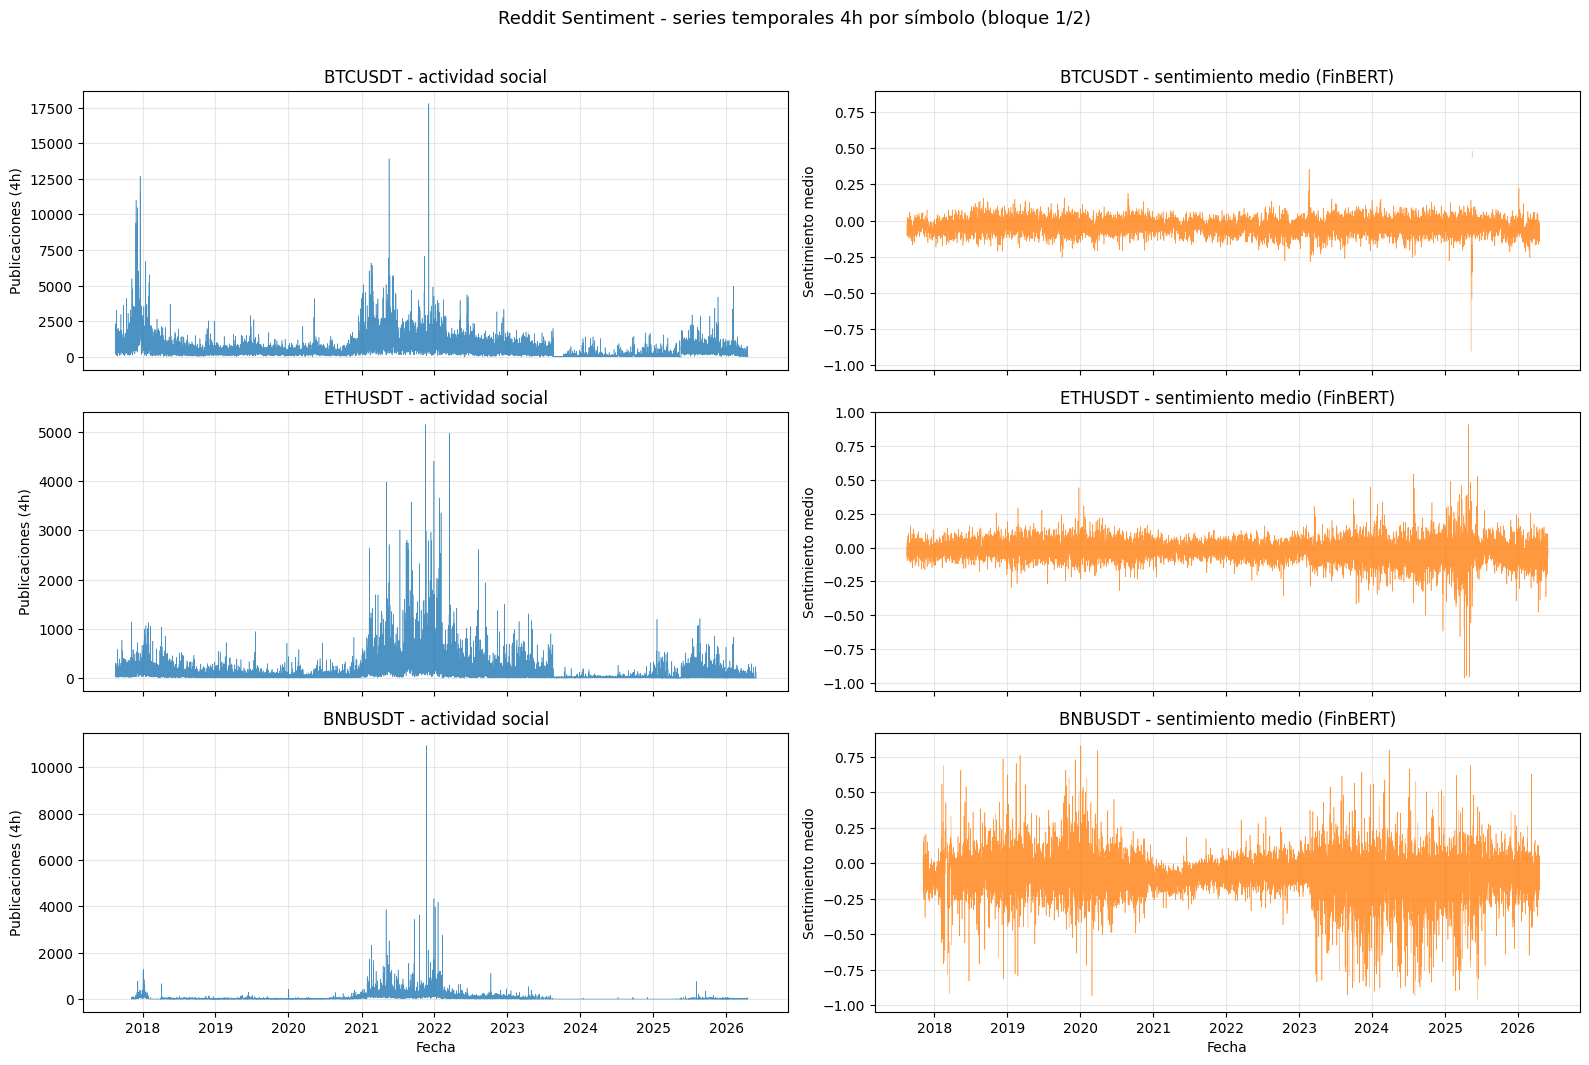

Figura guardada (bloque 1/2): /app/reports/validation/reddit/figures/reddit_series_4h_BLOCK1_20260604T001933Z.png


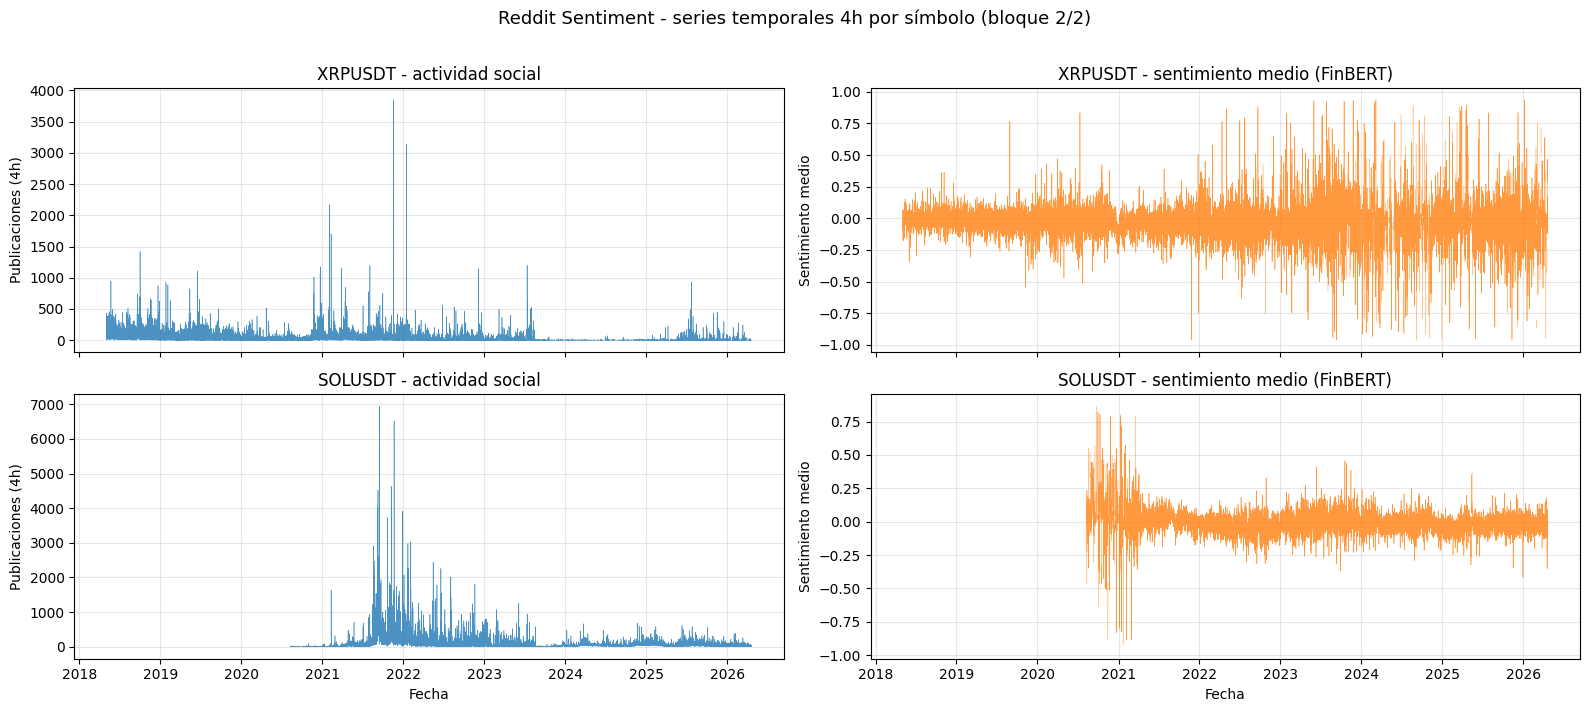

Figura guardada (bloque 2/2): /app/reports/validation/reddit/figures/reddit_series_4h_BLOCK2_20260604T001933Z.png


In [8]:
series_dict: dict[str, pd.DataFrame] = {}

if engine:
    for symbol in REDDIT_SYMBOLS:
        q = text(
            f"""
            SELECT bucket_4h,
                   comment_count,
                   submission_count,
                   sentiment_mean
            FROM {REDDIT_FULL_TABLE}
            WHERE symbol = :symbol
            ORDER BY bucket_4h
            """
        )
        df = pd.read_sql(q, engine, params={"symbol": symbol})
        if not df.empty:
            df["bucket_4h"] = pd.to_datetime(df["bucket_4h"])
            series_dict[symbol] = df

series_pares: list[tuple[str, pd.DataFrame]] = [
    (symbol, series_dict[symbol]) for symbol in REDDIT_SYMBOLS if symbol in series_dict
]

pares_por_bloque = 3
fig_series_path_part1 = None
fig_series_path_part2 = None

if series_pares:
    bloques: list[list[tuple[str, pd.DataFrame]]] = [series_pares[:pares_por_bloque]]
    if len(series_pares) > pares_por_bloque:
        bloques.append(series_pares[pares_por_bloque:])

    for bloque_idx, bloque in enumerate(bloques, start=1):
        n_filas = len(bloque)
        fig, axes = plt.subplots(
            n_filas,
            2,
            figsize=(16, 3.5 * n_filas),
            sharex=True,
        )
        if n_filas == 1:
            axes = [axes]

        for fila_idx, (symbol, df) in enumerate(bloque):
            ax_count, ax_sent = axes[fila_idx]

            total_posts = df["comment_count"] + df["submission_count"]
            ax_count.plot(df["bucket_4h"], total_posts, linewidth=0.4, alpha=0.8)
            ax_count.set_ylabel("Publicaciones (4h)")
            ax_count.set_title(f"{symbol} - actividad social")
            ax_count.xaxis.set_major_locator(mdates.YearLocator())
            ax_count.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax_count.grid(True, alpha=0.3)

            ax_sent.plot(
                df["bucket_4h"], df["sentiment_mean"],
                linewidth=0.4, alpha=0.8, color="tab:orange",
            )
            ax_sent.set_ylabel("Sentimiento medio")
            ax_sent.set_title(f"{symbol} - sentimiento medio (FinBERT)")
            ax_sent.xaxis.set_major_locator(mdates.YearLocator())
            ax_sent.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax_sent.grid(True, alpha=0.3)

        axes[-1][0].set_xlabel("Fecha")
        axes[-1][1].set_xlabel("Fecha")
        n_bloques = len(bloques)
        fig.suptitle(
            f"Reddit Sentiment - series temporales 4h por símbolo (bloque {bloque_idx}/{n_bloques})",
            fontsize=13,
            y=1.01,
        )
        plt.tight_layout()
        out_path = REDDIT_FIGURES_DIR / f"reddit_series_4h_BLOCK{bloque_idx}_{RUN_STAMP}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
        plt.show()
        print(f"Figura guardada (bloque {bloque_idx}/{n_bloques}): {out_path}")

        if bloque_idx == 1:
            fig_series_path_part1 = out_path
        else:
            fig_series_path_part2 = out_path
else:
    print("Sin datos para gráficar series temporales.")


### 5.2. Muestra de filas recientes

La muestra final por símbolo permite comprobar la forma de los registros más recientes sin convertir el cuaderno en una exploración exhaustiva de la tabla completa. Se incluyen tanto los conteos brutos como los componentes del scoring FinBERT (positivo, negativo, neutro), `coverage_ratio` y autores únicos.

In [9]:
muestras: dict[str, pd.DataFrame] = {}
COLUMNAS_MUESTRA_ES = {
    "symbol": "símbolo",
    "bucket_4h": "bucket_4h_utc",
    "comment_count": "num_comentarios",
    "submission_count": "num_publicaciones",
    "sentiment_mean": "sentimiento_medio",
    "sentiment_std": "desviacion_sentimiento",
    "sentiment_positive": "sentimiento_positivo",
    "sentiment_negative": "sentimiento_negativo",
    "sentiment_neutral": "sentimiento_neutro",
    "texts_analyzed": "textos_analizados",
    "unique_authors": "autores_únicos",
    "coverage_ratio": "ratio_cobertura",
    "ingested_at": "ingesta_utc",
}

if engine:
    for symbol in REDDIT_SYMBOLS:
        q = text(
            f"""
            SELECT symbol, bucket_4h,
                   comment_count, submission_count,
                   sentiment_mean, sentiment_std,
                   sentiment_positive, sentiment_negative, sentiment_neutral,
                   texts_analyzed, unique_authors, coverage_ratio,
                   ingested_at
            FROM {REDDIT_FULL_TABLE}
            WHERE symbol = :symbol
            ORDER BY bucket_4h DESC
            LIMIT 5
            """
        )
        muestras[symbol] = pd.read_sql(
            q, engine, params={"symbol": symbol}
        ).rename(columns=COLUMNAS_MUESTRA_ES)

for key, df in muestras.items():
    print(f"Muestra reciente: {key}")
    display(df)
    print("\n")


Muestra reciente: BTCUSDT


,símbolo,bucket_4h_utc,num_comentarios,num_publicaciones,sentimiento_medio,desviacion_sentimiento,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,textos_analizados,autores_únicos,ratio_cobertura,ingesta_utc
0,BTCUSDT,2026-04-19 20:00:00+00:00,0,15,-0.147867,0.425146,0.085714,0.200000,0.714286,35,34,0.921053,2026-04-20 14:13:41.684311+00:00
1,BTCUSDT,2026-04-19 16:00:00+00:00,1,33,-0.073396,0.209576,0.000000,0.061224,0.938776,49,41,0.980000,2026-04-20 14:13:41.684311+00:00
2,BTCUSDT,2026-04-19 12:00:00+00:00,0,33,-0.042791,0.247053,0.025641,0.102564,0.871795,39,31,0.906977,2026-04-20 14:13:41.684311+00:00
3,BTCUSDT,2026-04-19 08:00:00+00:00,0,14,-0.060415,0.147600,0.000000,0.038462,0.961538,26,25,0.962963,2026-04-20 14:13:41.684311+00:00
4,BTCUSDT,2026-04-19 04:00:00+00:00,0,9,-0.047972,0.095055,0.000000,0.000000,1.000000,13,14,0.928571,2026-04-20 14:13:41.684311+00:00




Muestra reciente: ETHUSDT


,símbolo,bucket_4h_utc,num_comentarios,num_publicaciones,sentimiento_medio,desviacion_sentimiento,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,textos_analizados,autores_únicos,ratio_cobertura,ingesta_utc
0,ETHUSDT,2026-05-30 20:00:00+00:00,0,0,-0.036707,0.222543,0.031250,0.09375,0.875000,32,16,0.941176,2026-05-31 03:23:58.463092+00:00
1,ETHUSDT,2026-05-30 16:00:00+00:00,0,0,-0.038140,0.224117,0.055556,0.00000,0.944444,18,14,0.900000,2026-05-31 03:23:58.463092+00:00
2,ETHUSDT,2026-05-30 12:00:00+00:00,0,0,-0.014857,0.271535,0.050000,0.05000,0.900000,20,16,0.833333,2026-05-31 03:23:58.463092+00:00
3,ETHUSDT,2026-05-30 08:00:00+00:00,0,0,-0.043220,0.062815,0.000000,0.00000,1.000000,6,7,0.857143,2026-05-31 03:23:58.463092+00:00
4,ETHUSDT,2026-05-30 04:00:00+00:00,1,1,-0.060785,0.107570,0.000000,0.00000,1.000000,6,10,0.600000,2026-05-31 03:23:58.463092+00:00




Muestra reciente: BNBUSDT


,símbolo,bucket_4h_utc,num_comentarios,num_publicaciones,sentimiento_medio,desviacion_sentimiento,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,textos_analizados,autores_únicos,ratio_cobertura,ingesta_utc
0,BNBUSDT,2026-04-19 20:00:00+00:00,4,9,-0.076951,0.197212,0.0,0.071429,0.928571,14,16,0.583333,2026-04-20 22:24:04.487800+00:00
1,BNBUSDT,2026-04-19 16:00:00+00:00,0,3,-0.006260,0.029339,0.0,0.000000,1.000000,5,7,0.714286,2026-04-20 22:24:04.487800+00:00
2,BNBUSDT,2026-04-19 12:00:00+00:00,0,0,-0.016282,0.011932,0.0,0.000000,1.000000,3,4,0.500000,2026-04-20 22:24:04.487800+00:00
3,BNBUSDT,2026-04-19 08:00:00+00:00,7,4,-0.032112,0.166561,0.0,0.000000,1.000000,7,9,0.700000,2026-04-20 22:24:04.487800+00:00
4,BNBUSDT,2026-04-19 04:00:00+00:00,1,5,0.048824,0.088804,0.0,0.000000,1.000000,8,9,0.800000,2026-04-20 22:24:04.487800+00:00




Muestra reciente: XRPUSDT


,símbolo,bucket_4h_utc,num_comentarios,num_publicaciones,sentimiento_medio,desviacion_sentimiento,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,textos_analizados,autores_únicos,ratio_cobertura,ingesta_utc
0,XRPUSDT,2026-04-20 20:00:00+00:00,0,0,-0.073715,0.11171,0.0,0.0,1.0,2,2,1.0,2026-04-21 00:07:17.386476+00:00
1,XRPUSDT,2026-04-20 16:00:00+00:00,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN,2026-04-21 00:07:17.386476+00:00
2,XRPUSDT,2026-04-20 12:00:00+00:00,0,1,0.055639,0.00000,0.0,0.0,1.0,1,1,1.0,2026-04-21 00:07:17.386476+00:00
3,XRPUSDT,2026-04-20 08:00:00+00:00,0,1,0.066854,0.00000,0.0,0.0,1.0,1,2,0.5,2026-04-21 00:07:17.386476+00:00
4,XRPUSDT,2026-04-20 04:00:00+00:00,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN,2026-04-21 00:07:17.386476+00:00




Muestra reciente: SOLUSDT


,símbolo,bucket_4h_utc,num_comentarios,num_publicaciones,sentimiento_medio,desviacion_sentimiento,sentimiento_positivo,sentimiento_negativo,sentimiento_neutro,textos_analizados,autores_únicos,ratio_cobertura,ingesta_utc
0,SOLUSDT,2026-04-20 20:00:00+00:00,5,4,-0.225008,0.415278,0.000000,0.250000,0.750000,4,4,1.000000,2026-04-21 02:40:02.111878+00:00
1,SOLUSDT,2026-04-20 16:00:00+00:00,8,8,-0.065348,0.158880,0.000000,0.000000,1.000000,10,10,0.909091,2026-04-21 02:40:02.111878+00:00
2,SOLUSDT,2026-04-20 12:00:00+00:00,4,5,-0.084578,0.230091,0.000000,0.166667,0.833333,6,6,0.857143,2026-04-21 02:40:02.111878+00:00
3,SOLUSDT,2026-04-20 08:00:00+00:00,16,10,0.070457,0.306347,0.103448,0.068966,0.827586,29,25,0.690476,2026-04-21 02:40:02.111878+00:00
4,SOLUSDT,2026-04-20 04:00:00+00:00,5,6,-0.056653,0.189170,0.000000,0.055556,0.944444,18,13,0.692308,2026-04-21 02:40:02.111878+00:00


## 6. Auditoría de ingesta

La evidencia técnica no se limita a la tabla fact. A partir de `alternative_data.ingestion_runs` se construye un **resumen por modo de ejecución** (`historico` vs. `live`) que cuantifica número de corridas, último arranque, filas totales y porcentaje de ejecuciones con fallo. Esta lectura permite distinguir si la tabla está sana porque el proceso terminó correctamente o si hay fallos recientes que conviene interpretar antes de usar la fuente en modelado.


In [10]:
advertencias_auditoria: list[str] = []
evidencia_runs_df = pd.DataFrame()

if engine:
    try:
        q_runs = text(
            """
            SELECT run_id,
                   pipeline_type,
                   started_at,
                   finished_at,
                   symbol_count,
                   tasks_total,
                   success_count,
                   failed_count,
                   total_rows
            FROM alternative_data.ingestion_runs
            WHERE pipeline_type IN (
                'etl_reddit_sentiment',
                'etl_reddit_sentiment_live',
                'etl_reddit_sentiment_backfill',
                'etl_reddit_sentiment_legacy',
                'etl_reddit_sentiment_repair',
                'etl_reddit'
            )
            ORDER BY started_at DESC
            LIMIT 50;
            """
        )
        evidencia_runs_df = pd.read_sql(q_runs, engine)
    except Exception as exc:
        advertencias_auditoria.append(f"No se pudo consultar ingestion_runs: {exc}")

evidencia_auditoria_df_full = evidencia_runs_df.copy()
resumen_modos_df = pd.DataFrame()

if not evidencia_auditoria_df_full.empty:
    evidencia_auditoria_df_full["modo"] = evidencia_auditoria_df_full["pipeline_type"].map(
        lambda x: "live" if "live" in str(x).lower() else "historico"
    )
    evidencia_auditoria_df_full["run_con_fallo"] = (
        evidencia_auditoria_df_full["failed_count"].fillna(0).astype(int) > 0
    )

    resumen_modos_df = (
        evidencia_auditoria_df_full.groupby("modo", as_index=False)
        .agg(
            ejecuciones=("run_id", "count"),
            ultimo_inicio=("started_at", "max"),
            total_filas=("total_rows", "sum"),
            total_fallos_eventos=("failed_count", "sum"),
            ejecuciones_con_fallo=("run_con_fallo", "sum"),
        )
        .sort_values("modo")
    )
    resumen_modos_df["pct_ejecuciones_con_fallo"] = (
        (resumen_modos_df["ejecuciones_con_fallo"] / resumen_modos_df["ejecuciones"]) * 100.0
    ).round(2)

if advertencias_auditoria:
    display(pd.DataFrame({"advertencia": advertencias_auditoria}))

print("\nResumen por modo de ejecución")
display(
    resumen_modos_df
    if not resumen_modos_df.empty
    else pd.DataFrame({"mensaje": ["No hay ejecuciones suficientes para derivar el resumen por modo."]})
)



Resumen por modo de ejecución


,modo,ejecuciones,ultimo_inicio,total_filas,total_fallos_eventos,ejecuciones_con_fallo,pct_ejecuciones_con_fallo
0,historico,1,2026-05-25 00:08:54.054309+00:00,6,0,0,0.0
1,live,49,2026-05-31 03:23:00.508257+00:00,72,0,0,0.0


## 7. Inventario de artefactos Parquet en disco

El inventario contrasta los ficheros raw esperados (uno por símbolo) con los artefactos disponibles bajo el directorio snapshot configurado para Reddit en `config/settings.yaml` (`alternative_data.reddit_sentiment.parquet.snapshot_dir`). El snapshot Parquet se materializa leyendo de la BD para reflejar el estado canónico tras ingesta + repair, por lo que esta evidencia permite reconstruir la tabla sin depender de una nueva llamada a la fuente externa y deja un respaldo en disco frente a la tabla materializada.

In [11]:
from src.config.settings import Settings

settings_inv = Settings.load_from_yaml(ROOT / "config" / "settings.yaml")
_rs = settings_inv.alternative_data.reddit_sentiment
REDDIT_RAW_DIR = Path(
    _rs.parquet.snapshot_dir
    if _rs is not None and getattr(_rs, "parquet", None) is not None
    else (ROOT / "data" / "01_raw" / "reddit_sentiment_parquet")
).resolve()
if not REDDIT_RAW_DIR.is_absolute():
    REDDIT_RAW_DIR = (ROOT / REDDIT_RAW_DIR).resolve()

parquet_rows: list[dict] = []
for _sym in REDDIT_SYMBOLS:
    archivo = f"reddit_sentiment_{_sym}.parquet"
    raw_path = REDDIT_RAW_DIR / archivo

    if not raw_path.exists():
        parquet_rows.append({
            "tipo": "raw_reddit_snapshot",
            "simbolo": _sym,
            "archivo": archivo,
            "tamano_mb": None,
            "filas": None,
            "columnas": None,
            "min_timestamp": None,
            "max_timestamp": None,
        })
        continue

    tamano_mb = raw_path.stat().st_size / (1024 * 1024)
    try:
        raw_df = pd.read_parquet(raw_path)
        timestamps = (
            pd.to_datetime(raw_df["bucket_4h"], utc=True, errors="coerce").dropna()
            if "bucket_4h" in raw_df.columns
            else pd.Series(dtype="datetime64[ns, UTC]")
        )
        parquet_rows.append({
            "tipo": "raw_reddit_snapshot",
            "simbolo": _sym,
            "archivo": archivo,
            "tamano_mb": round(tamano_mb, 2),
            "filas": len(raw_df),
            "columnas": len(raw_df.columns),
            "min_timestamp": timestamps.min() if not timestamps.empty else None,
            "max_timestamp": timestamps.max() if not timestamps.empty else None,
        })
    except Exception:
        parquet_rows.append({
            "tipo": "raw_reddit_snapshot",
            "simbolo": _sym,
            "archivo": archivo,
            "tamano_mb": round(tamano_mb, 2),
            "filas": None,
            "columnas": None,
            "min_timestamp": None,
            "max_timestamp": None,
        })

parquet_inventory_df = pd.DataFrame(parquet_rows)
display(parquet_inventory_df)


,tipo,simbolo,archivo,tamano_mb,filas,columnas,min_timestamp,max_timestamp
0,raw_reddit_snapshot,BTCUSDT,reddit_sentiment_BTCUSDT.parquet,0.73,19008,22,2017-08-17 00:00:00+00:00,2026-04-19 20:00:00+00:00
1,raw_reddit_snapshot,ETHUSDT,reddit_sentiment_ETHUSDT.parquet,0.74,19254,22,2017-08-17 00:00:00+00:00,2026-05-30 20:00:00+00:00
2,raw_reddit_snapshot,BNBUSDT,reddit_sentiment_BNBUSDT.parquet,0.64,18522,22,2017-11-06 00:00:00+00:00,2026-04-19 20:00:00+00:00
3,raw_reddit_snapshot,XRPUSDT,reddit_sentiment_XRPUSDT.parquet,0.59,17454,22,2018-05-04 00:00:00+00:00,2026-04-20 20:00:00+00:00
4,raw_reddit_snapshot,SOLUSDT,reddit_sentiment_SOLUSDT.parquet,0.48,12474,22,2020-08-11 00:00:00+00:00,2026-04-20 20:00:00+00:00


## 8. Exportación de artefactos para reproducibilidad

Las tablas vistas son útiles dentro del cuaderno, pero la memoria del TFG y la auditoría externa necesitan **artefactos persistentes** en disco. En esta celda se vuelca todo lo anterior bajo `reports/validation/reddit/`, con un sello UTC (`<stamp>`) en el nombre para no sobrescribir corridas previas (p. ej. `20260604T001031Z` en esta corrida).

- **JSON consolidado:** `reddit_validation_<stamp>.json` (metadatos, fecha de corte, símbolos, resultado global, `checks`, cobertura, duplicados, integridad, consistencia, auditoría, inventario *Parquet*, rutas de figuras).

- **Nueve CSV** (mismo `<stamp>`): `summary`, `cobertura`, `resumen_simbolos`, `duplicados`, `integridad`, `consistencia`, `modos`, `auditoria`, `parquet_inventory`.

- **Dos PNG** en `reports/validation/reddit/figures/`: `reddit_series_4h_BLOCK1_<stamp>.png` y `reddit_series_4h_BLOCK2_<stamp>.png` (sección 5).

Al final se imprime el **resultado global** (`PASS`/`FAIL`) y un mini-checklist (histórico, *live*, duplicados, integridad, *Parquet*), seguido de rutas del JSON, CSV y figuras. Por último se libera la conexión con `engine.dispose()` si el kernel sigue vivo.


In [12]:
export_paths = {
    "json": REDDIT_OUTPUT_DIR / f"reddit_validation_{RUN_STAMP}.json",
    "summary": REDDIT_OUTPUT_DIR / f"reddit_validation_summary_{RUN_STAMP}.csv",
    "cobertura": REDDIT_OUTPUT_DIR / f"reddit_validation_cobertura_{RUN_STAMP}.csv",
    "resumen_simbolos": REDDIT_OUTPUT_DIR / f"reddit_validation_resumen_simbolos_{RUN_STAMP}.csv",
    "duplicados": REDDIT_OUTPUT_DIR / f"reddit_validation_duplicados_{RUN_STAMP}.csv",
    "integridad": REDDIT_OUTPUT_DIR / f"reddit_validation_integridad_{RUN_STAMP}.csv",
    "consistencia": REDDIT_OUTPUT_DIR / f"reddit_validation_consistencia_{RUN_STAMP}.csv",
    "modos": REDDIT_OUTPUT_DIR / f"reddit_validation_modos_{RUN_STAMP}.csv",
    "auditoria": REDDIT_OUTPUT_DIR / f"reddit_validation_auditoria_{RUN_STAMP}.csv",
    "parquet_inventory": REDDIT_OUTPUT_DIR / f"reddit_validation_parquet_inventory_{RUN_STAMP}.csv",
}

duplicados_ok = bool(not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all())
integridad_ok = bool(not integridad_df.empty and len(integridad_df) >= len(REDDIT_SYMBOLS))
historico_ok = bool(not resumen_modos_df.empty and (resumen_modos_df["modo"] == "historico").any())
parquet_ok = bool(
    not parquet_inventory_df.empty
    and parquet_inventory_df["tamano_mb"].notna().sum() == len(parquet_inventory_df)
)
live_ok = bool(not resumen_modos_df.empty and (resumen_modos_df["modo"] == "live").any())

payload = {
    "metadata": run_meta,
    "fecha_corte": FECHA_CORTE,
    "simbolos": list(REDDIT_SYMBOLS),
    "resultado_global": "PASS" if accepted else "FAIL",
    "fallos_accionables": actionable_failures,
    "checks": summary_df.to_dict(orient="records"),
    "cobertura": {
        "detalle_por_simbolo": evidencia_cobertura_df.to_dict(orient="records") if not evidencia_cobertura_df.empty else [],
    },
    "duplicados_pk": {
        "verificado": duplicados_ok,
        "cero_duplicados_todos_simbolos": duplicados_ok,
        "detalle": duplicados_pk_df.to_dict(orient="records") if not duplicados_pk_df.empty else [],
    },
    "integridad_sentimiento": {
        "verificado": integridad_ok,
        "detalle": integridad_df.to_dict(orient="records") if not integridad_df.empty else [],
    },
    "consistencia": consistencia_df.to_dict(orient="records") if not consistencia_df.empty else [],
    "completitud_etl": {
        "historico_detectado": historico_ok,
        "live_detectado": live_ok,
    },
    "auditoria": {
        "resumen_modos": resumen_modos_df.to_dict(orient="records") if not resumen_modos_df.empty else [],
        "advertencias": advertencias_auditoria,
    },
    "inventario_parquet": {
        "archivos_encontrados": int(parquet_inventory_df["tamano_mb"].notna().sum()) if not parquet_inventory_df.empty else 0,
        "archivos_esperados": len(parquet_inventory_df) if not parquet_inventory_df.empty else 0,
        "detalle": parquet_inventory_df.to_dict(orient="records") if not parquet_inventory_df.empty else [],
    },
    "figuras": {
        "series_4h_png_bloque_1": str(fig_series_path_part1) if fig_series_path_part1 else None,
        "series_4h_png_bloque_2": str(fig_series_path_part2) if fig_series_path_part2 else None,
    },
}

export_paths["json"].write_text(json.dumps(payload, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
summary_df.to_csv(export_paths["summary"], index=False)
if not evidencia_cobertura_df.empty:
    evidencia_cobertura_df.to_csv(export_paths["cobertura"], index=False)
if not resumen_simbolos_df.empty:
    resumen_simbolos_df.to_csv(export_paths["resumen_simbolos"], index=False)
if not duplicados_pk_df.empty:
    duplicados_pk_df.to_csv(export_paths["duplicados"], index=False)
if not integridad_df.empty:
    integridad_df.to_csv(export_paths["integridad"], index=False)
if not consistencia_df.empty:
    consistencia_df.to_csv(export_paths["consistencia"], index=False)
if not resumen_modos_df.empty:
    resumen_modos_df.to_csv(export_paths["modos"], index=False)
if not evidencia_runs_df.empty:
    evidencia_runs_df.rename(columns=COLUMNAS_INGESTION_RUNS_ES).to_csv(export_paths["auditoria"], index=False)
if not parquet_inventory_df.empty:
    parquet_inventory_df.to_csv(export_paths["parquet_inventory"], index=False)

print(f"Resultado global: {'PASS' if accepted else 'FAIL'}")
print(f"Duplicados = 0 verificado: {'OK' if duplicados_ok else 'PENDIENTE'}")
print(f"Integridad de sentimiento por símbolo: {'OK' if integridad_ok else 'PENDIENTE'}")
print(f"Histórico detectado: {'OK' if historico_ok else 'PENDIENTE'}")
print(f"Live detectado: {'OK' if live_ok else 'PENDIENTE'}")
print(f"Inventario Parquet completo: {'OK' if parquet_ok else 'PENDIENTE'}")
print(f"Evidencia JSON: {export_paths['json']}")
for _name, _p in export_paths.items():
    if _name == "json":
        continue
    if _p.exists():
        print(f"CSV {_name}: {_p}")
if fig_series_path_part1:
    print(f"Figura series 4h (bloque 1): {fig_series_path_part1}")
if fig_series_path_part2:
    print(f"Figura series 4h (bloque 2): {fig_series_path_part2}")

if engine is not None:
    engine.dispose()


Resultado global: PASS
Duplicados = 0 verificado: OK
Integridad de sentimiento por símbolo: OK
Histórico detectado: OK
Live detectado: OK
Inventario Parquet completo: OK
Evidencia JSON: /app/reports/validation/reddit/reddit_validation_20260604T001933Z.json
CSV summary: /app/reports/validation/reddit/reddit_validation_summary_20260604T001933Z.csv
CSV cobertura: /app/reports/validation/reddit/reddit_validation_cobertura_20260604T001933Z.csv
CSV resumen_simbolos: /app/reports/validation/reddit/reddit_validation_resumen_simbolos_20260604T001933Z.csv
CSV duplicados: /app/reports/validation/reddit/reddit_validation_duplicados_20260604T001933Z.csv
CSV integridad: /app/reports/validation/reddit/reddit_validation_integridad_20260604T001933Z.csv
CSV consistencia: /app/reports/validation/reddit/reddit_validation_consistencia_20260604T001933Z.csv
CSV modos: /app/reports/validation/reddit/reddit_validation_modos_20260604T001933Z.csv
CSV auditoria: /app/reports/validation/reddit/reddit_validation_au

## 9. Conclusiones

Para el universo `{BTCUSDT, ETHUSDT, BNBUSDT, XRPUSDT, SOLUSDT}` en temporalidad 4h, esta ejecución (`stamp` `20260604T001031Z`, `fecha_hora_utc` **2026-06-04 00:10 UTC**) deja fijada una lectura en cuatro capas:

1. **Ingesta estructural**: resultado global `PASS`; las once comprobaciones requeridas en `PASS` (incluido `SENTIMENT_COVERAGE` y `FREEZE_COVERAGE`). Arranques observados alineados con lo esperado (`BTCUSDT`/`ETHUSDT` desde **2017-08-17**, `BNBUSDT` **2017-11-06**, `XRPUSDT` **2018-05-04**, `SOLUSDT` **2020-08-11**); `ETHUSDT` alcanza **2026-05-30 20:00 UTC** en `max_timestamp`.

2. **Cobertura e integridad**: **86,712** filas 4h agregadas en los cinco símbolos; **0** duplicados PK; `pct_sentimiento_real` entre **92.7 %** (XRP) y **99.9 %** (ETH) en esta corrida. Un `sentiment_mean` nulo indica ausencia de score *FinBERT*, no un hueco de mercado.

3. **Reproducibilidad**: histórico y *live* detectados (**50** ejecuciones: **1** histórico + **49** *live*; **6** / **72** filas reportadas por modo, **0 %** de ejecuciones con fallo); inventario *Parquet* **5/5**; JSON + nueve CSV + dos PNG (`reddit_series_4h_BLOCK1_20260604T001031Z.png`, `BLOCK2_...`) bajo `reports/validation/reddit/`.

4. **Limitación interpretativa**: Reddit aporta conversación social y tono dependientes del volumen de posts y del texto analizable. Complementa OHLCV y el resto del backbone, pero no sustituye precio ni volumen.

**Nota.** Resultado global, estados de `summary_df` y rutas con `stamp` dependen del estado del proyecto al ejecutar el cuaderno; en otra corrida pueden cambiar.